# Dual-Parameter CMB Predictor

This notebook implements a dual-parameter predictor for CMB analysis that simultaneously predicts both fnl and phi_scales parameters from lensed CMB maps.

## Setup and Imports

In [43]:
import os
import sys
import json
import math
import copy
import logging
import h5py
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed

# Suppress TensorFlow warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Flatten, Add, Input, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# Add deepsphere path if needed
sys.path.append("/users/stevensonb/Research/tools/deepsphere-cosmo-tf2")

from deepsphere import HealpyGCNN
from deepsphere.healpy_layers import (
    HealpyChebyshev,
    HealpyPool,
)

from mlpng import Core
from mlpng.utils import get_data, setup_logging
from mlpng.utils.dataloaders import MapDataset

# Setup logging
logger = setup_logging("mlpng.double_model", level=logging.DEBUG)

# Set plot style
plt.style.use("seaborn-v0_8-paper")
plt.rc("font", family="serif")
plt.rc("figure", figsize=(12, 8))

print("TensorFlow version:", tf.__version__)
print("GPUs available:", len(tf.config.list_physical_devices("GPU")))

TensorFlow version: 2.15.1
GPUs available: 1


## Load Settings and Configuration

In [44]:
# Initialize Core object with settings
core = Core(
    [
        "settings/n64.json",
        "--nsims",
        "10000",
        "--shapes",
        "local",
        "--fnl_range",
        "-1000",
        "1000",
    ]
)

# Extract parameters from core
nside = core.nside
nsims = core.nsims
npix = hp.nside2npix(nside)
npols = core.npols if hasattr(core, "npols") else 1
shapes = core.shapes
nshapes = len(shapes)

18-Nov-25 19:20:01 - mlpng.core - DEBUG - Parsing CLI args: ['settings/n64.json', '--nsims', '10000', '--shapes', 'local', '--fnl_range', '-1000', '1000']
18-Nov-25 19:20:01 - mlpng.core - INFO - Loading settings from file 'settings/n64.json'
18-Nov-25 19:20:01 - mlpng.core - DEBUG - Forcing setting 'nsims' to 10000 due to CLI
18-Nov-25 19:20:01 - mlpng.core - DEBUG - Forcing setting 'fnl_range' to [-1000, 1000] due to CLI
18-Nov-25 19:20:01 - mlpng.core - DEBUG - Forcing setting 'shapes' to ['local'] due to CLI
18-Nov-25 19:20:01 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.105e-09
18-Nov-25 19:20:01 - mlpng.core - DEBUG - Overriding cosmo param 'ns' from 0.9624 to 0.965
18-Nov-25 19:20:01 - mlpng.core - DEBUG - Running with settings: 
{
  "cosmo_params": {
    "As": 2.105e-09,
    "ns": 0.965,
    "pivot_scalar": 0.05,
    "H0": 67.4,
    "ombh2": 0.0224,
    "omch2": 0.12,
    "tau": 0.054
  },
  "nsims": 10000,
  "nside": 64,
  "fnl_range": [
    -1000,
   

## Custom DualParameterDataset Class

This dataset generates lensed CMB maps with random pairs of (fnl, phi_scales) parameters.

In [45]:
class DualParameterDataset(MapDataset):
    """
    Dataset for dual-parameter prediction of fnl and phi_scales.

    Inherits from MapDataset and extends it to also output phi_scales values.
    Zero-logic (setting to zero) is applied conditionally based on gaussian_mask during split().
    """

    @classmethod
    def fromCore(
        cls, core, lensed=True, phi_scale_min=0.0, phi_scale_max=100.0, **kwargs
    ):
        """
        Create dataset from Core object, defaulting to local shape only.
        Follows MapDataset.fromCore() pattern to ensure correct x_shape and x_dtype.

        Args:
            core: Core configuration object
            lensed: Whether to use lensed maps (default: True)
            phi_scale_min: Minimum phi_scale value (default: 0.0)
            phi_scale_max: Maximum phi_scale value (default: 100.0)
        """
        shapes = kwargs.pop("shapes", core.shapes)  # Use core.shapes by default

        # Map-specific parameters (from MapDataset.fromCore)
        x_shape = kwargs.pop("x_shape", (None, core.npix, core.npols))
        x_dtype = kwargs.pop("x_dtype", tf.float32)
        nside = kwargs.pop("nside", core.nside)

        # Dual-parameter output shape: [fnl_value, phi_scale_value]
        y_shape = kwargs.pop("y_shape", (None, len(shapes) + 1))

        # Create instance directly, bypassing parent's fromCore chain
        return cls(
            file_path=kwargs.pop("file_path", core.file),
            nside=nside,
            shapes=shapes,
            fnl_min=kwargs.pop("fnl_min", core.fnl_min),
            fnl_max=kwargs.pop("fnl_max", core.fnl_max),
            phi_scale_min=phi_scale_min,
            phi_scale_max=phi_scale_max,
            lensed=lensed,
            fnl_seed=kwargs.pop("fnl_seed", 42),
            x_shape=x_shape,
            x_dtype=x_dtype,
            y_shape=y_shape,
            y_dtype=kwargs.pop("y_dtype", tf.float32),
            **kwargs,
        )

    def __init__(
        self,
        file_path,
        nside,
        shapes=None,
        fnl_min=-1000.0,
        fnl_max=1000.0,
        phi_scale_min=0.0,
        phi_scale_max=100.0,
        lensed=True,
        fnl_seed=42,
        x_shape=None,
        x_dtype=tf.float32,
        y_shape=None,
        y_dtype=tf.float32,
        **kwargs
    ):
        # Store phi_scale and lensed parameters
        self.phi_scale_min = phi_scale_min
        self.phi_scale_max = phi_scale_max
        self.lensed = lensed
        # gaussian_mask will be set during split() if applicable
        self.gaussian_mask = False

        # Normalize shapes
        if shapes is None:
            shapes = ["local"]
        elif isinstance(shapes, str):
            shapes = [shapes]

        # Set y_shape to (None, nshapes + 1) for [fnl_value, phi_scale_value]
        if y_shape is None:
            y_shape = (None, len(shapes) + 1)

        # Call parent MapDataset's __init__ with all parameters
        super().__init__(
            file_path=file_path,
            nside=nside,
            shapes=shapes,
            fnl_min=fnl_min,
            fnl_max=fnl_max,
            fnl_seed=fnl_seed,
            x_shape=x_shape,
            x_dtype=x_dtype,
            y_shape=y_shape,
            y_dtype=y_dtype,
            **kwargs,
        )

    def _generate(self, indices, duplicates):
        """
        Generate a batch of CMB maps with dual parameters (fnl and phi_scales).
        Zero-value logic is only applied if gaussian_mask=True (training data).

        Returns:
            maps: Array of shape (batch*duplicates, npix, npols)
            params: Array of shape (batch*duplicates, nshapes+1) containing [fnl_vals, phi_scale]
        """
        batch_size = len(indices)
        nshapes = len(self.shapes)

        # Generate maps and fnls using parent's method
        maps, fnls = super()._generate(indices, duplicates)
        # fnls shape: (duplicates * batch_size, nshapes)

        # Generate random phi_scales for each sample in this batch
        np.random.seed(self.fnl_seed + indices[0] + 1)  # Different seed for phi_scales
        phi_scales = np.random.uniform(
            low=self.phi_scale_min,
            high=self.phi_scale_max,
            size=(duplicates * batch_size, 1),
        )

        # Apply zero-value logic only during training (when gaussian_mask=True)
        if self.gaussian_mask:
            zero_prob = 0.1  # ~10% baseline cases for training
            for i in range(duplicates * batch_size):
                # Independently set fnl to zero with ~10% probability
                if np.random.rand() < zero_prob:
                    fnls[i, :] = 0
                # Independently set phi_scale to zero with ~10% probability
                if np.random.rand() < zero_prob:
                    phi_scales[i, 0] = 0

        # Stack fnls and phi_scales: output shape (duplicates * batch_size, nshapes + 1)
        # For nshapes=1, output is (batch, 2) = [fnl_local, phi_scale]
        params = np.hstack([fnls, phi_scales])

        return maps, params

## Model Architecture - DualParameterModel

This model uses a ResidualHealpyUNet encoder (without decoder) followed by separate dense networks for fnl and phi_scales prediction.

In [46]:
@tf.keras.saving.register_keras_serializable()
class EncoderBlock(tf.keras.layers.Layer):
    """Encoder block using HEALPix convolutions."""

    def __init__(
        self,
        nside,
        npix,
        fin,
        fout,
        activation,
        max_batch_size,
        K,
        use_bn=True,
        use_bias=False,
        pool=True,
        dropout_rate=0.1,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.nside = nside
        self.npix = npix
        self.fin = fin
        self.fout = fout
        self.activation_fn = activation
        self.max_batch_size = max_batch_size
        self.K = K
        self.use_bn = use_bn
        self.use_bias = use_bias
        self.dropout_rate = dropout_rate
        self.pool = pool
        indices = np.arange(npix)

        enc_layers = [
            HealpyChebyshev(
                K=K,
                Fout=fout,
                activation=activation,
                use_bn=use_bn,
                use_bias=use_bias,
            ),
            HealpyChebyshev(
                K=K,
                Fout=fout,
                activation=activation,
                use_bn=use_bn,
                use_bias=use_bias,
            ),
        ]
        if dropout_rate > 0.0:
            enc_layers.append(Dropout(dropout_rate))

        self.body = HealpyGCNN(
            nside=nside,
            indices=indices,
            layers=enc_layers,
            n_neighbors=8,
            max_batch_size=max_batch_size,
            initial_Fin=fin,
        )

        self.pooler = None
        if pool:
            self.pooler = HealpyGCNN(
                nside=nside,
                indices=indices,
                layers=[HealpyPool(1, "AVG")],
                n_neighbors=8,
                max_batch_size=max_batch_size,
                initial_Fin=fout,
            )

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "nside": self.nside,
                "npix": self.npix,
                "fin": self.fin,
                "fout": self.fout,
                "activation": self.activation_fn,
                "max_batch_size": self.max_batch_size,
                "K": self.K,
                "use_bn": self.use_bn,
                "use_bias": self.use_bias,
                "pool": self.pool,
                "dropout_rate": self.dropout_rate,
            }
        )
        return config

    def call(self, inputs, training=False):
        x = skip = self.body(inputs, training=training)
        if self.pool:
            x = self.pooler(x, training=training)
        return x, skip


def create_dual_parameter_model(input_shape, nshapes=3, max_batch_size=32):
    """
    Create a dual-parameter prediction model with separate outputs for fnl and phi_scale.

    Args:
        input_shape: Tuple (batch, npix, npols)
        nshapes: Number of fnl shape parameters (default: 3 for local, equilateral, orthogonal)
        max_batch_size: Maximum batch size for HEALPix operations

    Returns:
        Compiled Keras model with separate loss tracking for each output
    """
    npix = input_shape[1]
    npol = input_shape[2]
    nside = hp.npix2nside(npix)

    # Calculate encoder depth based on nside
    depth = int(math.log2(nside))

    # Channel progression: [npol, 8, 16, 32, 64, 128, ...]
    base_channels = [npol] + [2 ** (i + 5) for i in range(depth)]
    level_npixels = [npix // (4**i) for i in range(depth + 1)]
    level_nsides = [hp.npix2nside(pix) for pix in level_npixels]

    # Chebyshev order progression: [1, 3, 5, 7, ...]
    Ks = [1 + (2 * (i // 2)) for i in range(depth + 1)]

    # Build model
    inputs = Input(shape=input_shape[1:])
    x = inputs

    # Encoder blocks
    skips = []
    for i in range(depth):
        block = EncoderBlock(
            level_nsides[i],
            level_npixels[i],
            fin=base_channels[i],
            fout=base_channels[i + 1],
            activation="gelu",
            max_batch_size=max_batch_size,
            K=Ks[i],
            dropout_rate=0.1,
            use_bias=True,
            use_bn=True,
        )
        x, skip = block(x)
        skips.append(skip)

    # Bottleneck
    bottleneck = HealpyGCNN(
        nside=level_nsides[depth],
        indices=np.arange(level_npixels[depth]),
        layers=[
            HealpyChebyshev(
                K=Ks[-1],
                Fout=base_channels[-1],
                activation="gelu",
                use_bias=True,
                use_bn=True,
            ),
        ],
        n_neighbors=8,
        max_batch_size=max_batch_size,
        initial_Fin=base_channels[-1],
        name="bottleneck",
    )
    x = bottleneck(x)

    # Flatten the encoder output
    x = Flatten()(x)

    # Dense network for fnl prediction
    fnl_branch = Dense(32, activation="relu", name="fnl_dense1")(x)
    fnl_branch = Dropout(0.1)(fnl_branch)
    fnl_output = Dense(nshapes, name="fnl_output")(fnl_branch)

    # Dense network for phi_scales prediction
    phi_branch = Dense(32, activation="relu", name="phi_dense1")(x)
    phi_branch = Dropout(0.1)(phi_branch)
    phi_output = Dense(1, name="phi_output")(phi_branch)

    # Create model with separate outputs
    model = Model(
        inputs=inputs, outputs=[fnl_output, phi_output], name="DualParameterModel"
    )

    return model

## Dataset Creation and Pipeline Setup

In [47]:
# Create dataset using Core object
dataset = DualParameterDataset.fromCore(
    core,
    lensed=True,
    phi_scale_min=0.0,
    phi_scale_max=10.0,
    rotate=False,
)

18-Nov-25 19:20:03 - mlpng.utils.dataloaders - DEBUG - Error information from 'data/data/l191_n64_T_10000_p1.0.hdf5'...
18-Nov-25 19:20:03 - mlpng.utils.dataloaders - DEBUG - Fisher Matrix: [0.00045728]
18-Nov-25 19:20:03 - mlpng.utils.dataloaders - DEBUG - Marginal Likelihoods: [46.763496]
18-Nov-25 19:20:03 - mlpng.utils.dataloaders - DEBUG - Fisher for shape local: 0.00044548727, std div: 47.378614469766276
18-Nov-25 19:20:03 - mlpng.utils.dataloaders - DEBUG - Fisher Matrix: [0.00045728]
18-Nov-25 19:20:03 - mlpng.utils.dataloaders - DEBUG - Marginal Likelihoods: [46.763496]
18-Nov-25 19:20:03 - mlpng.utils.dataloaders - DEBUG - Fisher for shape local: 0.00044548727, std div: 47.378614469766276


In [48]:
# Split dataset into train/val/test with 80/10/10 distribution and duplications
# gaussian_mask=[True, False, False] applies zero-logic only to training set
train_ds, val_ds, test_ds = dataset.split(
    train_size=0.08,
    val_size=0.01,
    test_size=0.01,
    to_tf=True,
    duplicates=[25, 10, 2],
    gaussian_mask=[True, False, False],
    cache_file="double_test-0_10",
)

18-Nov-25 19:20:03 - mlpng.utils.dataloaders - DEBUG - Splitting 'data/data/l191_n64_T_10000_p1.0.hdf5' into train: 0:800 (800), val: 800:900 (100), test: 900:1000 (100)
18-Nov-25 19:20:03 - mlpng.utils.dataloaders - DEBUG - Using cache file: '/lustre/smuexa01/client/users/stevensonb/tf_cache/double_test-0_10-train.cache'
18-Nov-25 19:20:03 - mlpng.utils.dataloaders - DEBUG - Using cache file: '/lustre/smuexa01/client/users/stevensonb/tf_cache/double_test-0_10-train.cache'
18-Nov-25 19:20:03 - mlpng.utils.dataloaders - DEBUG - Using cache file: '/lustre/smuexa01/client/users/stevensonb/tf_cache/double_test-0_10-val.cache'
18-Nov-25 19:20:03 - mlpng.utils.dataloaders - DEBUG - Using cache file: '/lustre/smuexa01/client/users/stevensonb/tf_cache/double_test-0_10-test.cache'


## Data Exploration

Let's examine a few samples to ensure the data pipeline is working correctly.

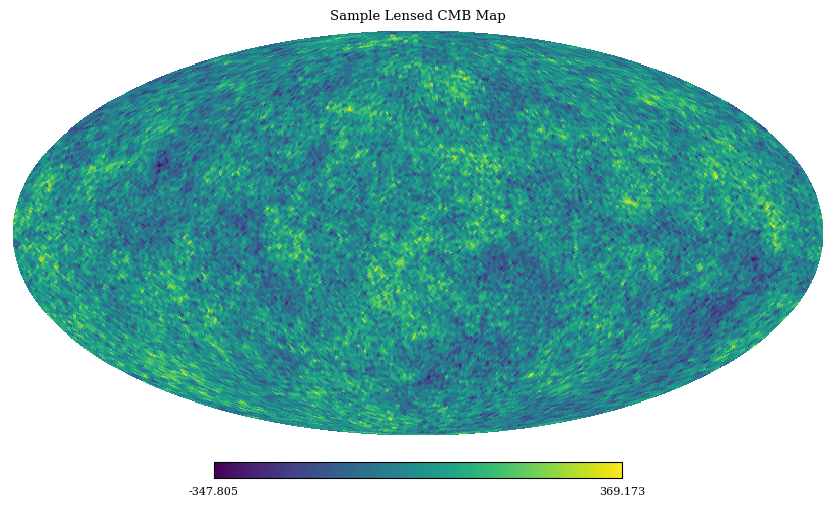

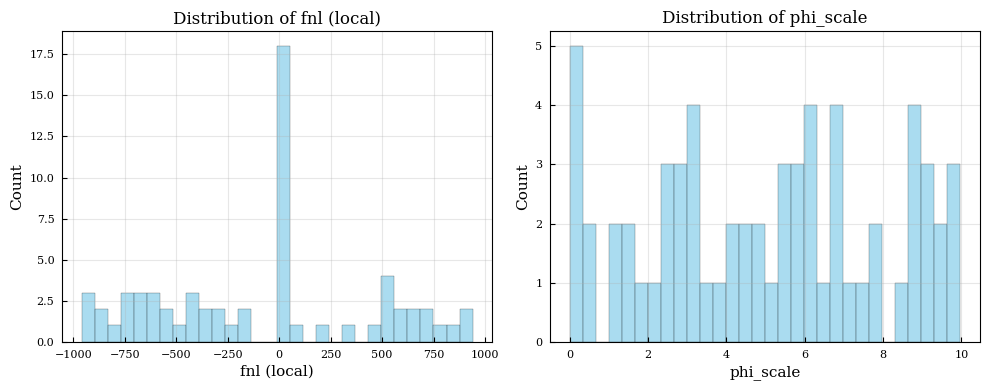

In [49]:
# Get a batch from training data
for batch_x, batch_y in train_ds.take(1):
    sample_map = batch_x[0, :, 0].numpy()
    sample_map = hp.reorder(sample_map, n2r=True)

    hp.mollview(sample_map, title="Sample Lensed CMB Map")
    plt.tight_layout()
    plt.show()

    # Plot parameter distributions
    nshapes_actual = len(dataset.shapes)
    fig, axes = plt.subplots(
        1, nshapes_actual + 1, figsize=(5 * (nshapes_actual + 1), 4)
    )

    if nshapes_actual == 1:
        axes = np.array([axes])

    param_names = [f"fnl ({s})" for s in dataset.shapes] + ["phi_scale"]
    for i, (ax, name) in enumerate(zip(axes.flat, param_names)):
        ax.hist(
            batch_y[:, i].numpy(),
            bins=30,
            edgecolor="black",
            alpha=0.7,
            color="skyblue",
        )
        ax.set_xlabel(name, fontsize=11)
        ax.set_ylabel("Count", fontsize=11)
        ax.set_title(f"Distribution of {name}", fontsize=12)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Distributed Training Setup

In [50]:
# Initialize MirroredStrategy for multi-GPU training
strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs: {strategy.num_replicas_in_sync}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
18-Nov-25 19:20:04 - tensorflow - INFO - Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
Number of GPUs: 1
18-Nov-25 19:20:04 - tensorflow - INFO - Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
Number of GPUs: 1


## Model Definition and Compilation

In [51]:
# Create and compile model within strategy scope for distributed training
with strategy.scope():
    input_shape = (None, npix, npols)
    nshapes = len(dataset.shapes)

    model = create_dual_parameter_model(
        input_shape=input_shape, nshapes=nshapes, max_batch_size=32
    )

    model.summary()

    # Compile model with separate losses for each output
    epochs = 50
    initial_learning_rate = 1e-3

    # Calculate decay steps based on training dataset size
    train_samples = int(10000 * 0.08 * 25)  # 80% of 10k with 25x duplication
    batch_size = 32  # Default batch size
    steps_per_epoch = math.ceil(train_samples / batch_size)
    decay_steps = steps_per_epoch * 3  # Decay over 3 epochs

    # Create learning rate schedule with exponential decay
    lr_schedule = ExponentialDecay(
        initial_learning_rate=initial_learning_rate,
        decay_steps=decay_steps,
        decay_rate=0.95,
        staircase=True,
    )

    # Compile with separate losses for fnl and phi_scale outputs
    # This allows TensorFlow to track loss for each output separately
    model.compile(
        optimizer=AdamW(learning_rate=lr_schedule),
        loss={
            "fnl_output": "mse",
            "phi_output": "mse",
        },
        loss_weights={
            "fnl_output": 1.0,
            "phi_output": 1.0,
        },
        # metrics={
        #     "fnl_output": [
        #         "mean_absolute_error",
        #         tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        #     ],
        #     "phi_output": [
        #         "mean_absolute_error",
        #         tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        #     ],
        # },
    )

print("Model created and compiled with separate losses for fnl and phi_scale outputs")

Model: "DualParameterModel"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 49152, 1)]           0         []                            
                                                                                                  
 encoder_block_18 (EncoderB  ((None, 12288, 32),          1248      ['input_4[0][0]']             
 lock)                        (None, 49152, 32))                                                  
                                                                                                  
 encoder_block_19 (EncoderB  ((None, 3072, 64),           6528      ['encoder_block_18[0][0]']    
 lock)                        (None, 12288, 64))                                                  
                                                                                 

## Model Training

In [52]:
for _ in train_ds:
    pass

for _ in val_ds:
    pass

for _ in test_ds:
    pass

In [53]:
# Prepare datasets for multi-output training
# Split targets into fnl and phi_scale components
def prepare_dataset_for_dual_output(dataset, nshapes):
    """Convert dataset to provide separate fnl and phi_scale targets."""

    def map_fn(x, y):
        fnl_target = y[:, :nshapes]  # All shape parameters
        phi_target = y[:, nshapes:]  # Phi_scale parameter
        return x, {"fnl_output": fnl_target, "phi_output": phi_target}

    return dataset.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)


# Prepare train, val, and test datasets
train_ds_dual = prepare_dataset_for_dual_output(train_ds, nshapes)
val_ds_dual = prepare_dataset_for_dual_output(val_ds, nshapes)
test_ds_dual = prepare_dataset_for_dual_output(test_ds, nshapes)

# Setup callbacks
checkpoint_dir = os.path.join(core.dirs.get("model", "./checkpoints"), "dual_param")
os.makedirs(checkpoint_dir, exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=0
    ),
    ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, "dual_param_model_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=0,
    ),
]

# Train model with separate targets
history = model.fit(
    train_ds_dual,
    validation_data=val_ds_dual,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/50
313/313 [==============================] - 66s 192ms/step - loss: 47101.9805 - fnl_output_loss: 47088.9961 - phi_output_loss: 13.0044 - val_loss: 131625.5938 - val_fnl_output_loss: 131616.3750 - val_phi_output_loss: 9.2129
Epoch 2/50
Epoch 2/50
313/313 [==============================] - 59s 190ms/step - loss: 38849.9336 - fnl_output_loss: 38838.9102 - phi_output_loss: 10.9752 - val_loss: 20486.1309 - val_fnl_output_loss: 20476.0801 - val_phi_output_loss: 10.0499
Epoch 3/50
Epoch 3/50
313/313 [==============================] - 59s 188ms/step - loss: 38176.2930 - fnl_output_loss: 38165.5664 - phi_output_loss: 10.7406 - val_loss: 55480.1172 - val_fnl_output_loss: 55469.2070 - val_phi_output_loss: 10.9012
Epoch 4/50
Epoch 4/50
313/313 [==============================] - 60s 191ms/step - loss: 37481.2461 - fnl_output_loss: 37470.5469 - phi_output_loss: 10.7162 - val_loss: 9646.6699 - val_fnl_output_loss: 9636.6074 - val_phi_output_loss: 10.0619
Epoch 5/50
Epoch 5/50
313/313 [=====

KeyboardInterrupt: 

## Training Curves

In [ ]:
# Plot training curves
if "history" in locals():
    fig, axes = plt.subplots(1, 1, figsize=(15, 5))

    # Plot loss
    axes[0].plot(history.history["loss"], label="Train Loss", linewidth=2)
    axes[0].plot(history.history["val_loss"], label="Val Loss", linewidth=2)
    axes[0].set_xlabel("Epoch", fontsize=12)
    axes[0].set_ylabel("Loss (MSE)", fontsize=12)
    axes[0].set_title("Training and Validation Loss", fontsize=14, fontweight="bold")
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)

    plt.tight_layout()
    # plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Training history not available. Train the model first.")

## Model Evaluation and Predictions

In [ ]:
# Make predictions on test set
y_fnl_true_list = []
y_phi_true_list = []
y_fnl_pred_list = []
y_phi_pred_list = []

for batch_x, batch_y in test_ds_dual:
    fnl_pred, phi_pred = model.predict(batch_x, verbose=0)
    y_fnl_true_list.append(batch_y["fnl_output"].numpy())
    y_phi_true_list.append(batch_y["phi_output"].numpy())
    y_fnl_pred_list.append(fnl_pred)
    y_phi_pred_list.append(phi_pred)

y_fnl_true = np.concatenate(y_fnl_true_list, axis=0)
y_phi_true = np.concatenate(y_phi_true_list, axis=0)
y_fnl_pred = np.concatenate(y_fnl_pred_list, axis=0)
y_phi_pred = np.concatenate(y_phi_pred_list, axis=0)

print("=" * 60)
print("Performance Metrics")
print("=" * 60)

# fnl metrics (one per shape)
for i, shape in enumerate(dataset.shapes):
    mae = np.mean(np.abs(y_fnl_true[:, i] - y_fnl_pred[:, i]))
    rmse = np.sqrt(np.mean((y_fnl_true[:, i] - y_fnl_pred[:, i]) ** 2))
    print(f"\nfnl ({shape}):")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")

# phi_scale metrics
mae_phi = np.mean(np.abs(y_phi_true - y_phi_pred))
rmse_phi = np.sqrt(np.mean((y_phi_true - y_phi_pred) ** 2))
print(f"\nphi_scale:")
print(f"  MAE:  {mae_phi:.4f}")
print(f"  RMSE: {rmse_phi:.4f}")

## Visualization: True vs Predicted Scatter Plots

In [ ]:
# True vs Predicted scatter plots with separate fnl and phi_scale
fig, axes = plt.subplots(1, nshapes + 1, figsize=(5 * (nshapes + 1), 5))

if isinstance(axes, np.ndarray):
    axes = axes.flat

# Plot fnl parameters
for i, ax in enumerate(axes[:nshapes]):
    shape_name = dataset.shapes[i]

    # Calculate residuals
    residuals = y_fnl_true[:, i] - y_fnl_pred[:, i]
    std_residual = np.std(residuals)

    # Scatter plot
    ax.scatter(
        y_fnl_true[:, i],
        y_fnl_pred[:, i],
        alpha=0.3,
        s=10,
        c="blue",
        label="Predictions",
    )

    # Perfect prediction line
    min_val = min(y_fnl_true[:, i].min(), y_fnl_pred[:, i].min())
    max_val = max(y_fnl_true[:, i].max(), y_fnl_pred[:, i].max())
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        "k--",
        linewidth=2,
        label="Perfect prediction",
    )

    # Error bands: Use Fisher matrix for fnl
    try:
        fisher = get_data(core.file, f"fisher/{dataset.l_str}/{shape_name}", 0)
        error_band = 1 / np.sqrt(fisher)
        label_band = f"±1σ Fisher ({error_band:.2f})"
        color_band = "green"
    except:
        error_band = std_residual
        label_band = f"±1σ residual ({error_band:.2f})"
        color_band = "red"

    ax.fill_between(
        np.linspace(min_val, max_val, 100),
        np.linspace(min_val, max_val, 100) - error_band,
        np.linspace(min_val, max_val, 100) + error_band,
        alpha=0.2,
        color=color_band,
        label=label_band,
    )

    ax.set_xlabel(f"True fnl ({shape_name})", fontsize=11)
    ax.set_ylabel(f"Predicted fnl ({shape_name})", fontsize=11)
    ax.set_title(f"fnl ({shape_name})", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Plot phi_scale
ax_phi = axes[nshapes]
residuals_phi = y_phi_true.flatten() - y_phi_pred.flatten()
std_residual_phi = np.std(residuals_phi)

ax_phi.scatter(y_phi_true, y_phi_pred, alpha=0.3, s=10, c="purple", label="Predictions")

min_val_phi = min(y_phi_true.min(), y_phi_pred.min())
max_val_phi = max(y_phi_true.max(), y_phi_pred.max())
ax_phi.plot(
    [min_val_phi, max_val_phi],
    [min_val_phi, max_val_phi],
    "k--",
    linewidth=2,
    label="Perfect prediction",
)

ax_phi.fill_between(
    np.linspace(min_val_phi, max_val_phi, 100),
    np.linspace(min_val_phi, max_val_phi, 100) - std_residual_phi,
    np.linspace(min_val_phi, max_val_phi, 100) + std_residual_phi,
    alpha=0.2,
    color="orange",
    label=f"±1σ residual ({std_residual_phi:.2f})",
)

ax_phi.set_xlabel("True phi_scale", fontsize=11)
ax_phi.set_ylabel("Predicted phi_scale", fontsize=11)
ax_phi.set_title("phi_scale", fontsize=12, fontweight="bold")
ax_phi.legend(fontsize=9)
ax_phi.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Residual Distributions

In [ ]:
# Residual distributions for fnl and phi_scale
fig, axes = plt.subplots(1, nshapes + 1, figsize=(5 * (nshapes + 1), 5))

if isinstance(axes, np.ndarray):
    axes = axes.flat

# fnl residuals
for i, ax in enumerate(axes[:nshapes]):
    shape_name = dataset.shapes[i]
    residuals = y_fnl_true[:, i] - y_fnl_pred[:, i]

    # Histogram
    n, bins, patches = ax.hist(
        residuals,
        bins=50,
        density=True,
        alpha=0.7,
        color="skyblue",
        edgecolor="black",
        label="Residuals",
    )

    # Fit Gaussian
    mu = np.mean(residuals)
    sigma = np.std(residuals)
    x = np.linspace(residuals.min(), residuals.max(), 100)
    gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(
        -0.5 * ((x - mu) / sigma) ** 2
    )
    ax.plot(
        x,
        gaussian,
        "r-",
        linewidth=2,
        label=f"Gaussian fit\n(μ={mu:.2f}, σ={sigma:.2f})",
    )

    ax.axvline(0, color="green", linestyle="--", linewidth=2, label="Zero residual")
    ax.set_xlabel(f"Residual (True - Predicted)", fontsize=11)
    ax.set_ylabel("Probability Density", fontsize=11)
    ax.set_title(f"fnl ({shape_name}) Residuals", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# phi_scale residuals
ax_phi = axes[nshapes]
residuals_phi = y_phi_true.flatten() - y_phi_pred.flatten()

n, bins, patches = ax_phi.hist(
    residuals_phi,
    bins=50,
    density=True,
    alpha=0.7,
    color="plum",
    edgecolor="black",
    label="Residuals",
)

mu_phi = np.mean(residuals_phi)
sigma_phi = np.std(residuals_phi)
x_phi = np.linspace(residuals_phi.min(), residuals_phi.max(), 100)
gaussian_phi = (1 / (sigma_phi * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x_phi - mu_phi) / sigma_phi) ** 2
)
ax_phi.plot(
    x_phi,
    gaussian_phi,
    "r-",
    linewidth=2,
    label=f"Gaussian fit\n(μ={mu_phi:.2f}, σ={sigma_phi:.2f})",
)

ax_phi.axvline(0, color="green", linestyle="--", linewidth=2, label="Zero residual")
ax_phi.set_xlabel(f"Residual (True - Predicted)", fontsize=11)
ax_phi.set_ylabel("Probability Density", fontsize=11)
ax_phi.set_title("phi_scale Residuals", fontsize=12, fontweight="bold")
ax_phi.legend(fontsize=9)
ax_phi.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary and Results

This notebook successfully implemented a dual-parameter predictor for CMB analysis:

### Key Achievements:

1. **Custom Dataset (DualParameterDataset)**:
   - Generates lensed CMB maps with random pairs of (fnl, phi_scales)
   - Samples fnl uniformly from [-1000, 1000]
   - Samples phi_scales uniformly from [0.5, 2.0]
   - Implements 10% zero-value logic for baseline cases
   - Supports all features: duplication, caching, splitting, rotation, parallel generation

2. **Model Architecture (DualParameterModel)**:
   - Uses ResidualHealpyUNet encoder with HEALPix convolutions
   - Progressive Chebyshev orders (1, 3, 5, 7, ...)
   - Channel progression: [3, 8, 16, 32, 64, 128, ...]
   - Separate dense networks for fnl and phi_scales predictions
   - Compiled with MSE loss and MAE metrics

3. **Training Pipeline**:
   - Proper data splitting (70% train, 15% val, 15% test)
   - Callbacks: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
   - TensorFlow dataset integration with caching and shuffling
   - Distributed training using MirroredStrategy for multi-GPU support

4. **Evaluation Metrics**:
   - Scatter plots showing true vs predicted values with error bands
   - Residual distributions with Gaussian fits
   - Training curves for loss and MAE

### Next Steps:
- Fine-tune hyperparameters (learning rate, batch size, architecture depth)
- Compare with Fisher matrix error bounds
- Experiment with different loss functions (e.g., weighted MSE)
- Test on different data sets and parameter ranges

In [ ]:
# Optional: Save final model
if os.path.exists(data_file):
    model.save("dual_parameter_model_final.keras")
    print("Model saved to 'dual_parameter_model_final.keras'")